In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

In [3]:
df = pd.read_csv('../datasets/titanic_toy.csv')

In [4]:
df.head()

,Age,Fare,Family,Survived
0,22.0,7.2500,1,0
1,38.0,71.2833,1,1
2,26.0,7.9250,0,1
3,35.0,53.1000,1,1
4,35.0,8.0500,0,0


In [5]:
df.isnull().mean()

Age         0.198653
Fare        0.050505
Family      0.000000
Survived    0.000000
dtype: float64

In [6]:
X = df.drop('Survived', axis=1)
y = df['Survived']

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [8]:
numerical_cols = X_train.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = X_train.select_dtypes(include=['object']).columns

In [9]:
X_train['Age_99'] = X_train['Age'].fillna(99)
X_train['Age_minus1'] = X_train['Age'].fillna(-1)

X_train['Fare_999'] = X_train['Fare'].fillna(999)
X_train['Fare_minus1'] = X_train['Fare'].fillna(-1)

In [10]:
print('Original Age variable variance: ', X_train['Age'].var())
print('Age Variance after 99 wala imputation: ', X_train['Age_99'].var())
print('Age Variance after -1 wala imputation: ', X_train['Age_minus1'].var())

print('Original Fare variable variance: ', X_train['Fare'].var())
print('Fare Variance after 999 wala imputation: ', X_train['Fare_999'].var())
print('Fare Variance after -1 wala imputation: ', X_train['Fare_minus1'].var())

Original Age variable variance:  213.7165085187575
Age Variance after 99 wala imputation:  934.1249575238231
Age Variance after -1 wala imputation:  321.6688109349073
Original Fare variable variance:  2574.352620663723
Fare Variance after 999 wala imputation:  50926.92292430495
Fare Variance after -1 wala imputation:  2489.213857315901


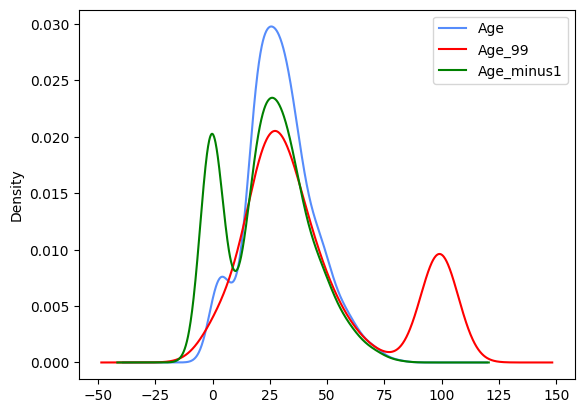

In [11]:
fig = plt.figure()
ax = fig.add_subplot(111)

# original variable distribution
X_train['Age'].plot(kind='kde', ax=ax)

# variable imputed with the median
X_train['Age_99'].plot(kind='kde', ax=ax, color='red')

# variable imputed with the mean
X_train['Age_minus1'].plot(kind='kde', ax=ax, color='green')

# add legends
lines, labels = ax.get_legend_handles_labels()
ax.legend(lines, labels, loc='best')

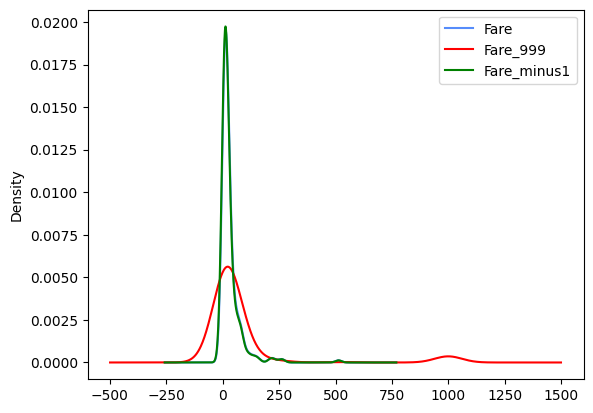

In [14]:
fig = plt.figure()
ax = fig.add_subplot(111)

# original variable distribution
X_train['Fare'].plot(kind='kde', ax=ax)

# variable imputed with the median
X_train['Fare_999'].plot(kind='kde', ax=ax, color='red')

# variable imputed with the mean
X_train['Fare_minus1'].plot(kind='kde', ax=ax, color='green')

# add legends
lines, labels = ax.get_legend_handles_labels()
ax.legend(lines, labels, loc='best')

In [15]:
X_train.cov()

,Age,Fare,Family,Age_99,Age_minus1,Fare_999,Fare_minus1
Age,213.716509,84.480223,-6.393469,213.716509,213.716509,87.899997,79.287836
Fare,84.480223,2574.352621,17.050423,-49.762911,119.548363,2574.352621,2574.352621
Family,-6.393469,17.050423,2.770177,-5.506430,-4.956484,6.685344,16.435815
Age_99,213.716509,-49.762911,-5.506430,934.124958,-167.301760,-202.695108,-41.740249
Age_minus1,213.716509,119.548363,-4.956484,-167.301760,321.668811,191.737330,110.313200
Fare_999,87.899997,2574.352621,6.685344,-202.695108,191.737330,50926.922924,784.183690
Fare_minus1,79.287836,2574.352621,16.435815,-41.740249,110.313200,784.183690,2489.213857


In [17]:
X_train.corr()

,Age,Fare,Family,Age_99,Age_minus1,Fare_999,Fare_minus1
Age,1.000000,0.106334,-0.295318,1.000000,1.000000,0.025986,0.102325
Fare,0.106334,1.000000,0.198661,-0.031926,0.130702,1.000000,1.000000
Family,-0.295318,0.198661,1.000000,-0.108247,-0.166041,0.017799,0.197928
Age_99,1.000000,-0.031926,-0.108247,1.000000,-0.305206,-0.029388,-0.027373
Age_minus1,1.000000,0.130702,-0.166041,-0.305206,1.000000,0.047373,0.123280
Fare_999,0.025986,1.000000,0.017799,-0.029388,0.047373,1.000000,0.069649
Fare_minus1,0.102325,1.000000,0.197928,-0.027373,0.123280,0.069649,1.000000


In [24]:
# Using Sklearn's SimpleImputer for arbitrary value imputation
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [25]:
arbitrary_imputer = ColumnTransformer(
    transformers=[
        ('num_99', SimpleImputer(strategy='constant', fill_value=99), ['Age']),
        ('num_minus1', SimpleImputer(strategy='constant', fill_value=-1), ['Age']),
        ('num_999', SimpleImputer(strategy='constant', fill_value=999), ['Fare']),
        ('num_minus1_fare', SimpleImputer(strategy='constant', fill_value=-1), ['Fare'])
    ],
    remainder='passthrough'
)

In [26]:
X_train_arbitrary = arbitrary_imputer.fit_transform(X_train)
X_test_arbitrary = arbitrary_imputer.transform(X_test)

In [27]:
print('Original Age variable variance: ', X_train['Age'].var())
print('Age Variance after 99 wala imputation: ', X_train_arbitrary[:,0].var())
print('Age Variance after -1 wala imputation: ', X_train_arbitrary[:,1].var())


Original Age variable variance:  213.7165085187575
Age Variance after 99 wala imputation:  932.812984268874
Age Variance after -1 wala imputation:  321.21702889707734


In [28]:
print('Original Fare variable variance: ', X_train['Fare'].var())
print('Fare Variance after 999 wala imputation: ', X_train_arbitrary[:,2].var())
print('Fare Variance after -1 wala imputation: ', X_train_arbitrary[:,3].var())

Original Fare variable variance:  2574.352620663723
Fare Variance after 999 wala imputation:  50855.396347164075
Fare Variance after -1 wala imputation:  2485.717770437648


In [31]:
X_train

,Age,Fare,Family
140,NaN,15.2458,2
439,31.0,10.5000,0
817,31.0,37.0042,2
378,20.0,NaN,0
491,21.0,7.2500,0
...,...,...,...
835,39.0,83.1583,2
192,19.0,7.8542,1
629,NaN,7.7333,0
559,36.0,17.4000,1
